In [1]:
import pickle
import glob
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from CMR_IA.fitting import make_boundary

In [2]:
print("Available past fits:", sorted(os.listdir("past_fits")))

Available past fits: ['5_260822_200-200', '6b_260823_200-200', '7_260825_200-200', '8_260826_200-200', 'S2_260827_200-200']


In [3]:
# Choose which fit to inspect:
#   "ongoing" -> the live fit currently writing to outfiles/
#   "<name>"  -> a past fit saved under past_fits/ (listed below)
FIT_SOURCE = "S2_260827_200-200"  # "6a_260816_100-50"
SIMU_NAME = "S2"  # simulation id, used to label the fitted parameters
PARAM_IDX = 7    # which fitted parameter to track

In [4]:
# Resolve the output directory and the parameter name for the chosen fit
if FIT_SOURCE == "ongoing":
    OUTDIR = "outfiles/"
else:
    OUTDIR = f"past_fits/{FIT_SOURCE}/outfiles/"
    SIMU_NAME = FIT_SOURCE.split("_")[0]  # infer simu id from folder name
assert os.path.isdir(OUTDIR), f"Not found: {OUTDIR}"

try:
    _, _, what_to_fit = make_boundary(SIMU_NAME)
    PARAM_NAME = what_to_fit[PARAM_IDX]
except Exception:
    PARAM_NAME = f"param[{PARAM_IDX}]"

print("Reading from:", OUTDIR)
print("Tracking parameter:", PARAM_NAME)

Reading from: past_fits/S2_260827_200-200/outfiles/
Tracking parameter: c_thresh_assoc


In [5]:
err_list = glob.glob(f"{OUTDIR}err_iter*")
all_iters = [int(os.path.basename(err).replace("err_iter", "")) for err in err_list]
max_iter = max(all_iters)
max_iter

200

In [6]:
file_list = glob.glob(f"{OUTDIR}*data*.pkl")
fit_iter_part = [os.path.basename(i).replace(".pkl", "") for i in file_list]
fit_iter_part = [tuple(map(int, i.split("data"))) for i in fit_iter_part]
fit_iter_part.sort()
fit_iter_part = [i for i in fit_iter_part if i[0] <= max_iter]

In [7]:
rows = []
for it, p in fit_iter_part:
    path = f"{OUTDIR}{it}data{p}.pkl"
    with open(path, "rb") as inp:
        data = pickle.load(inp)
    try:
        err = data["err"]
        b = data["params"][PARAM_IDX]
    except Exception:
        err = np.nan
        b = np.nan
    rows.append({"iter": it, "particle": p, "err": err, "para": b})
pso_df = pd.DataFrame(rows)
pso_df

,iter,particle,err,para
0,1,0,12882.541933,0.948572
1,1,1,16770.694449,0.864207
2,1,2,12668.218550,0.991100
3,1,3,19746.217529,1.724695
4,1,4,21196.014874,0.816007
...,...,...,...,...
39995,200,195,476.564081,1.054439
39996,200,196,476.003056,1.055072
39997,200,197,476.524773,1.055006
39998,200,198,483.353259,1.055181


In [8]:
pso_df["iter"] = pd.to_numeric(pso_df["iter"])
pso_df.groupby("iter").err.min()

iter
1      4403.755246
2      3274.470903
3      1475.576440
4      1252.833761
5      1474.287526
          ...     
196     475.986633
197     475.970287
198     475.970287
199     475.970287
200     475.970287
Name: err, Length: 200, dtype: float64

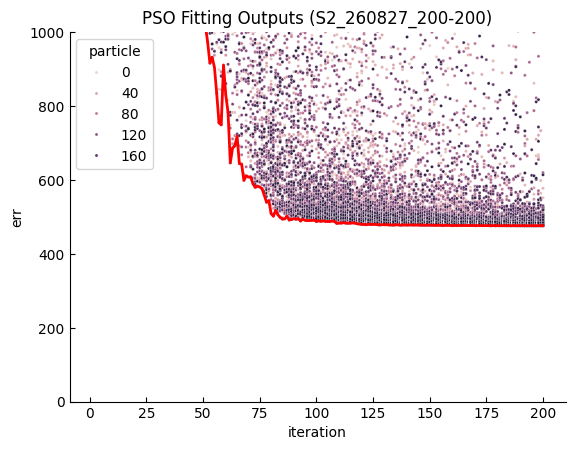

In [12]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="err", hue="particle", s=5)
plt.plot(pso_df.groupby("iter").err.min(), lw=2, color="r")
plt.ylabel("err")
plt.xlabel("iteration")
plt.ylim([0, 1000])
# ax.legend().set_visible(False)
plt.title(f"PSO Fitting Outputs ({FIT_SOURCE})")
plt.show()

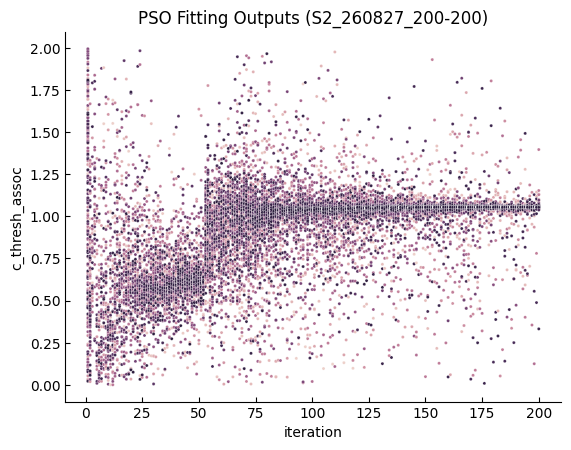

In [10]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="para", hue="particle", s=5)
plt.ylabel(PARAM_NAME)
plt.xlabel("iteration")
# plt.ylim([400000, 600000])
ax.legend().set_visible(False)
plt.title(f"PSO Fitting Outputs ({FIT_SOURCE})")
plt.show()